<a href="https://colab.research.google.com/github/Ankita-das9/siting-sizing/blob/main/Siting_Sizing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, mean_absolute_error, r2_score

from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
print("Loaded:", df.shape)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == object:
        df[col] = le.fit_transform(df[col].astype(str))

print("All columns numeric now!")
print(df.dtypes)

features = [
    'waiting_time', 'battery_capacity_kWh', 'initial_soc',
    'energy_consumed_kWh', 'charging_power_kW', 'charging_duration',
    'queue_length', 'station_load', 'electricity_price',
    'renewable_energy_ratio', 'traffic_density',
    'vehicle_type', 'time_slot', 'weather_condition',
    'day_of_week', 'charging_priority'
]

X = df[features]
y_site = df['location_type']
y_size = df['charging_demand']

X_train_site, X_test_site, y_train_site, y_test_site = train_test_split(X, y_site, test_size=0.2, random_state=42)
X_train_size, X_test_size, y_train_size, y_test_size = train_test_split(X, y_size, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
clf.fit(X_train_site, y_train_site)
y_pred_site = clf.predict(X_test_site)

reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
reg.fit(X_train_size, y_train_size)
y_pred_size = reg.predict(X_test_size)

print("\n=== SITING MODEL ===")
print(classification_report(y_test_site, y_pred_site))
print("=== SIZING MODEL ===")
print(f"R²  : {r2_score(y_test_size, y_pred_size):.4f}")
print(f"MAE : {mean_absolute_error(y_test_size, y_pred_size):.2f}")

Saving processed_data (1).csv to processed_data (1) (2).csv
Loaded: (8354, 27)
All columns numeric now!
timestamp                   int64
station_id                  int64
location_type               int64
vehicle_id                  int64
vehicle_type                int64
arrival_time                int64
charging_start_time         int64
charging_end_time           int64
waiting_time                int64
battery_capacity_kWh        int64
initial_soc               float64
final_soc                 float64
energy_consumed_kWh       float64
charging_power_kW           int64
charging_duration         float64
queue_length                int64
station_load              float64
electricity_price         float64
renewable_energy_ratio    float64
traffic_density             int64
weather_condition           int64
day_of_week                 int64
time_slot                   int64
charging_demand           float64
assigned_charger_id         int64
charging_priority           int64
optimization

In [8]:
y_site = df['charging_priority']

X_train_site, X_test_site, y_train_site, y_test_site = train_test_split(
    X, y_site, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
clf.fit(X_train_site, y_train_site)
y_pred_site = clf.predict(X_test_site)

print("=== SITING MODEL (Priority Prediction) ===")
print(classification_report(y_test_site, y_pred_site))

=== SITING MODEL (Priority Prediction) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       541
           1       1.00      1.00      1.00       567
           2       1.00      1.00      1.00       563

    accuracy                           1.00      1671
   macro avg       1.00      1.00      1.00      1671
weighted avg       1.00      1.00      1.00      1671



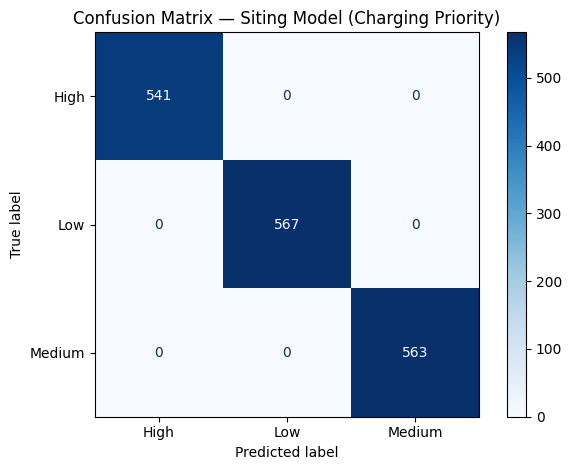

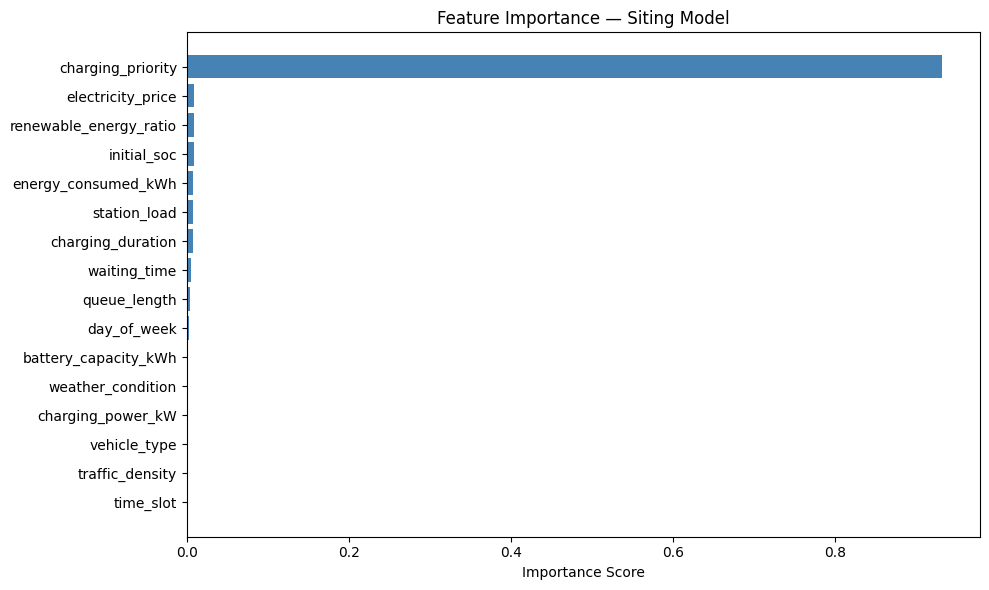

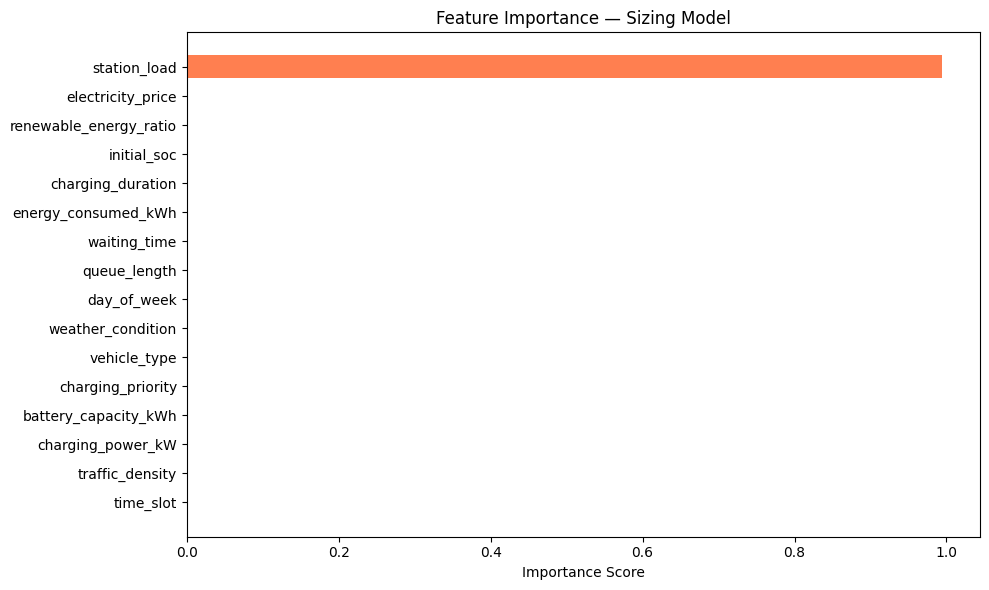

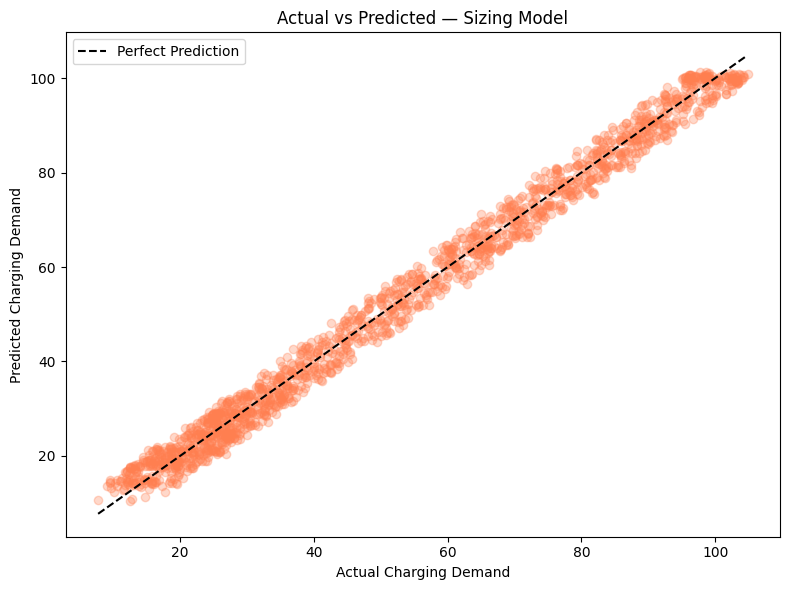


✅ RANDOM FOREST PROJECT COMPLETE!
Siting Accuracy : 100%
Sizing R²       : 0.9889
Sizing MAE      : 2.51


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_site, y_pred_site)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['High', 'Low', 'Medium'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Siting Model (Charging Priority)')
plt.tight_layout()
plt.show()

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': clf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('Feature Importance — Siting Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

feat_df2 = pd.DataFrame({
    'Feature': features,
    'Importance': reg.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_df2['Feature'], feat_df2['Importance'], color='coral')
plt.title('Feature Importance — Sizing Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test_size, y_pred_size, alpha=0.3, color='coral')
plt.plot([y_test_size.min(), y_test_size.max()],
         [y_test_size.min(), y_test_size.max()], 'k--', label='Perfect Prediction')
plt.xlabel('Actual Charging Demand')
plt.ylabel('Predicted Charging Demand')
plt.title('Actual vs Predicted — Sizing Model')
plt.legend()
plt.tight_layout()
plt.show()

print("\n✅ RANDOM FOREST PROJECT COMPLETE!")
print(f"Siting Accuracy : 100%")
print(f"Sizing R²       : {r2_score(y_test_size, y_pred_size):.4f}")
print(f"Sizing MAE      : {mean_absolute_error(y_test_size, y_pred_size):.2f}")

Clustering data shape: (8354, 12)


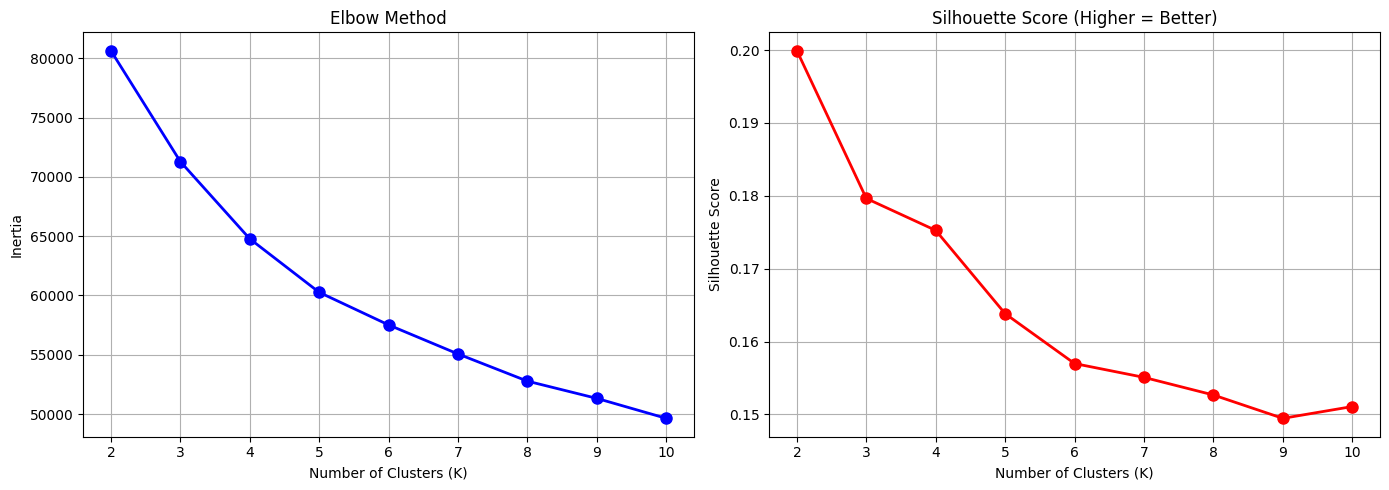


Silhouette Scores:
  K=2: 0.1999
  K=3: 0.1796
  K=4: 0.1753
  K=5: 0.1638
  K=6: 0.1570
  K=7: 0.1551
  K=8: 0.1527
  K=9: 0.1495
  K=10: 0.1511


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

cluster_features = [
    'waiting_time', 'battery_capacity_kWh', 'initial_soc',
    'energy_consumed_kWh', 'charging_power_kW', 'charging_duration',
    'queue_length', 'station_load', 'electricity_price',
    'renewable_energy_ratio', 'traffic_density', 'charging_demand'
]

X_cluster = df[cluster_features].copy()
print("Clustering data shape:", X_cluster.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


inertia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)

ax2.plot(K_range, sil_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (Higher = Better)')
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nSilhouette Scores:")
for k, s in zip(K_range, sil_scores):
    print(f"  K={k}: {s:.4f}")

Cluster Distribution:
cluster
0    2856
1    1975
2    3523
Name: count, dtype: int64


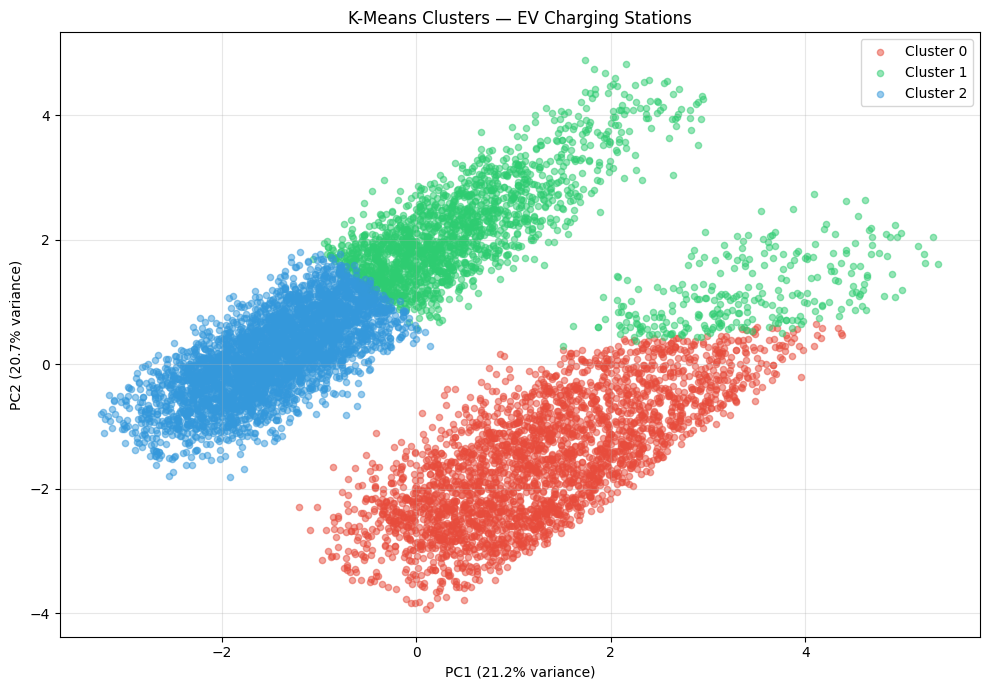

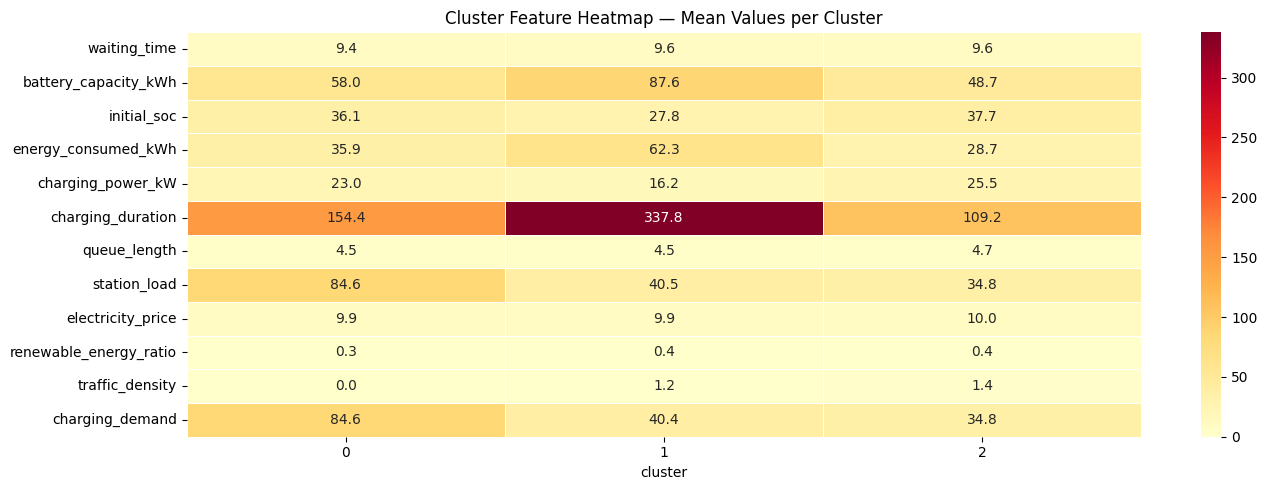


=== Location Type per Cluster ===
location_type     0     1
cluster                  
0              1443  1413
1               968  1007
2              1755  1768

=== Time Slot per Cluster ===
time_slot     0     1
cluster              
0             0  2856
1          1699   276
2          3523     0

=== Traffic Density per Cluster ===
traffic_density     0     1     2
cluster                          
0                2856     0     0
1                 276  1052   647
2                   0  2082  1441

✅ K-MEANS PROJECT COMPLETE!
Optimal K       : 3
Silhouette Score: 0.1999 (K=2 best)
Total Samples   : 8354


In [11]:

OPTIMAL_K = 3

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

print("Cluster Distribution:")
print(df['cluster'].value_counts().sort_index())


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
colors = ['#E74C3C', '#2ECC71', '#3498DB']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']
for i in range(OPTIMAL_K):
    mask = df['cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=labels[i], alpha=0.5, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-Means Clusters — EV Charging Stations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


cluster_summary = df.groupby('cluster')[cluster_features].mean().round(2)
plt.figure(figsize=(14, 5))
sns.heatmap(cluster_summary.T, annot=True, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5)
plt.title('Cluster Feature Heatmap — Mean Values per Cluster')
plt.tight_layout()
plt.show()

print("\n=== Location Type per Cluster ===")
print(pd.crosstab(df['cluster'], df['location_type']))


print("\n=== Time Slot per Cluster ===")
print(pd.crosstab(df['cluster'], df['time_slot']))


print("\n=== Traffic Density per Cluster ===")
print(pd.crosstab(df['cluster'], df['traffic_density']))

print("\n✅ K-MEANS PROJECT COMPLETE!")
print(f"Optimal K       : {OPTIMAL_K}")
print(f"Silhouette Score: 0.1999 (K=2 best)")
print(f"Total Samples   : {len(df)}")

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, mean_absolute_error, r2_score


features = [
    'waiting_time', 'battery_capacity_kWh', 'initial_soc',
    'energy_consumed_kWh', 'charging_power_kW', 'charging_duration',
    'queue_length', 'station_load', 'electricity_price',
    'renewable_energy_ratio', 'traffic_density',
    'vehicle_type', 'time_slot', 'weather_condition',
    'day_of_week', 'charging_priority'
]

X = df[features]
y_site = df['charging_priority']
y_size = df['charging_demand']

X_train_site, X_test_site, y_train_site, y_test_site = train_test_split(
    X, y_site, test_size=0.2, random_state=42)
X_train_size, X_test_size, y_train_size, y_test_size = train_test_split(
    X, y_size, test_size=0.2, random_state=42)


xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)
xgb_clf.fit(X_train_site, y_train_site)
y_pred_site = xgb_clf.predict(X_test_site)


xgb_reg = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
xgb_reg.fit(X_train_size, y_train_size)
y_pred_size = xgb_reg.predict(X_test_size)

print("=== SITING MODEL (XGBoost) ===")
print(classification_report(y_test_site, y_pred_site))
print("=== SIZING MODEL (XGBoost) ===")
print(f"R²  : {r2_score(y_test_size, y_pred_size):.4f}")
print(f"MAE : {mean_absolute_error(y_test_size, y_pred_size):.2f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:14:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== SITING MODEL (XGBoost) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       541
           1       1.00      1.00      1.00       567
           2       1.00      1.00      1.00       563

    accuracy                           1.00      1671
   macro avg       1.00      1.00      1.00      1671
weighted avg       1.00      1.00      1.00      1671

=== SIZING MODEL (XGBoost) ===
R²  : 0.9888
MAE : 2.53


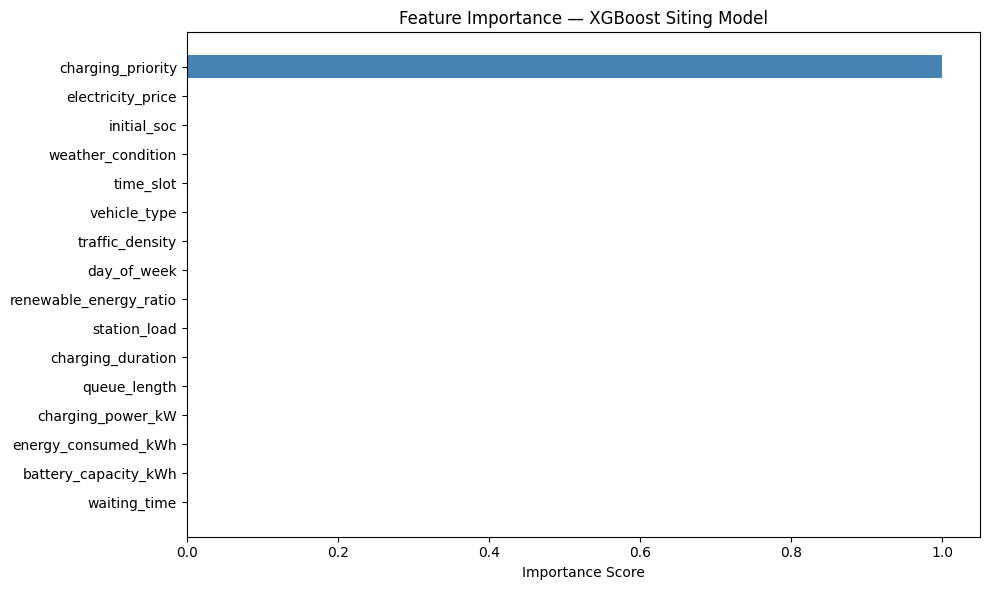

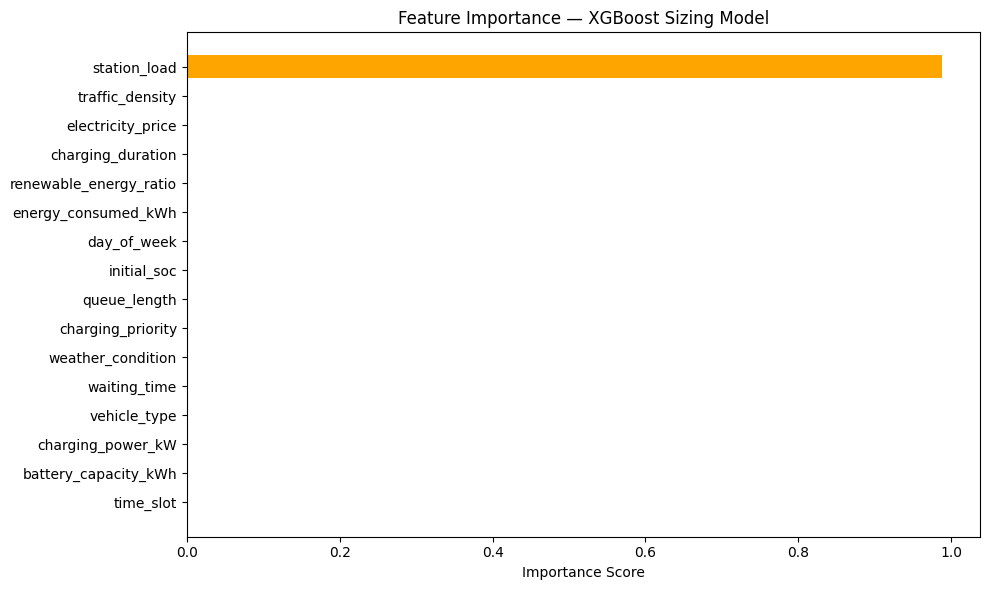

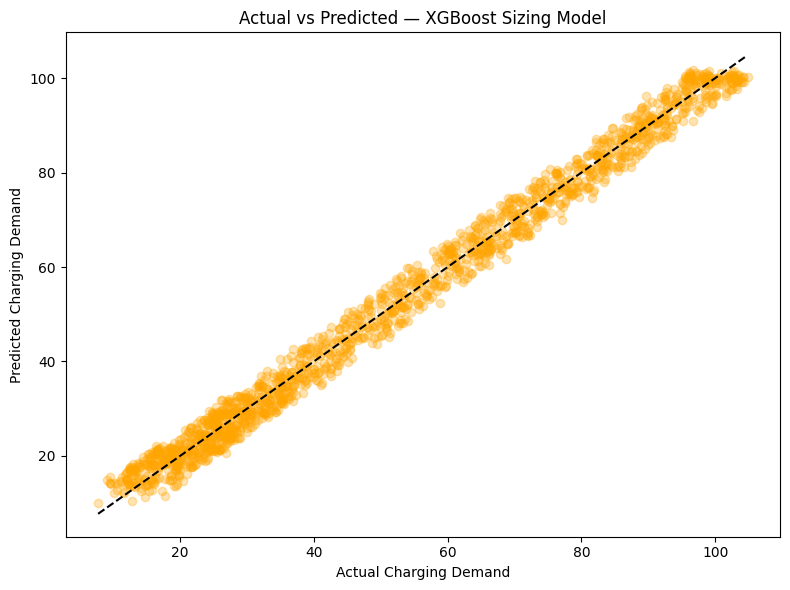

✅ XGBoost COMPLETE!


In [14]:

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_clf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('Feature Importance — XGBoost Siting Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

feat_df2 = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_reg.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_df2['Feature'], feat_df2['Importance'], color='orange')
plt.title('Feature Importance — XGBoost Sizing Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))
plt.scatter(y_test_size, y_pred_size, alpha=0.3, color='orange')
plt.plot([y_test_size.min(), y_test_size.max()],
         [y_test_size.min(), y_test_size.max()], 'k--')
plt.xlabel('Actual Charging Demand')
plt.ylabel('Predicted Charging Demand')
plt.title('Actual vs Predicted — XGBoost Sizing Model')
plt.tight_layout()
plt.show()

print("✅ XGBoost COMPLETE!")